# __<u>Site Information: </u>__
> __Site # 01__
>>  - Location: **Ansan-si, Gyeonggi-do**
>>  - Solar Plants: 2
>>>    - Plant 1: C_scode **414241001.0**
>>>    - Plant 2: C_scode **414241002.0**
>>  - Weather Station: 1
>>>    - Weather Station info: **414244001** : 

# __<u>Initialize Cloud-AI Engine</u>__ 
> Selected python version == 3.11
>> To access cmd: py -3.11 -m pip ....

> Install/Verify Packages

In [38]:
# %pip install --user --upgrade pandas
# %pip install --user --upgrade "sqlalchemy<2.0"
# %pip install --user --upgrade mariadb
# %pip install --user --upgrade -U matplotlib

> Import Libraries

In [39]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from datetime import time
import random

In [40]:
import sys, os
sys.path.append(os.path.abspath('..'))   # add the IGPS project root to the path

In [41]:
import importlib
import Library.dataProcessing
importlib.reload(Library.dataProcessing)

<module 'Library.dataProcessing' from 'f:\\RBM\\Educational\\UTS.au\\Research\\[P] KMU==IGPS in Solar Plants\\Firmware\\IGPS\\Library\\dataProcessing.py'>

# __<u>Configure Simulation Setup</u>__

>Define output directory

In [42]:
# Preprocessed data directory
preDataDirectory = '../../Database/2026-06-14/Preprocessed/'

# Root directory for the project
mainDirectory   = '../Export/'

# Define subdirectories for data, models, and figures
dataDirectory   = mainDirectory + 'Data/'
modelDirectory  = mainDirectory + 'Model/'
figDirectory    = mainDirectory + 'Figure/'

# create dataDirectory if it doesn't exist
if not os.path.exists(dataDirectory):
    os.makedirs(dataDirectory)
    print(f"System has created \"{dataDirectory}\" directory.")
else:
    print(f"The directory \"{dataDirectory}\" already exists.")

# create modelDirectory if it doesn't exist
if not os.path.exists(modelDirectory):
    os.makedirs(modelDirectory)
    print(f"System has created \"{modelDirectory}\" directory.")
else:
    print(f"The directory \"{modelDirectory}\" already exists.")


# create figDirectory if it doesn't exist
if not os.path.exists(figDirectory):
    os.makedirs(figDirectory)
    print(f"System has created \"{figDirectory}\" directory.")
else:
    print(f"The directory \"{figDirectory}\" already exists.")

The directory "../Export/Data/" already exists.
The directory "../Export/Model/" already exists.
The directory "../Export/Figure/" already exists.


> Define colunmns and rows of pandas output

In [43]:
import pandas as pd
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 30)

# __<u>Data Processing for Model Development and Testing</u>__

In [44]:
PV1 = pd.read_csv(f"{preDataDirectory}PV_Plant_414241001.csv")
PV2 = pd.read_csv(f"{preDataDirectory}PV_Plant_414241002.csv")
ENV = pd.read_csv(f"{preDataDirectory}Weather_Station_414244001.csv")

> Filter only effective data
>> Note:
>> We have considered Instantaneous Output Data of Each PV

In [45]:
rename_columns = {
    'DT': 'timestamp',
    'P_ac': 'P_pv',
    }
PV1.rename(columns=rename_columns, inplace=True)
PV2.rename(columns=rename_columns, inplace=True)
ENV.rename(columns=rename_columns, inplace=True)

> Visualize Data

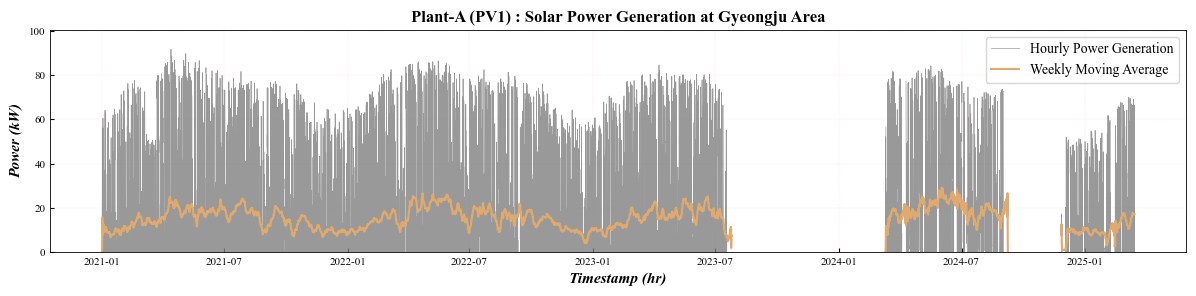

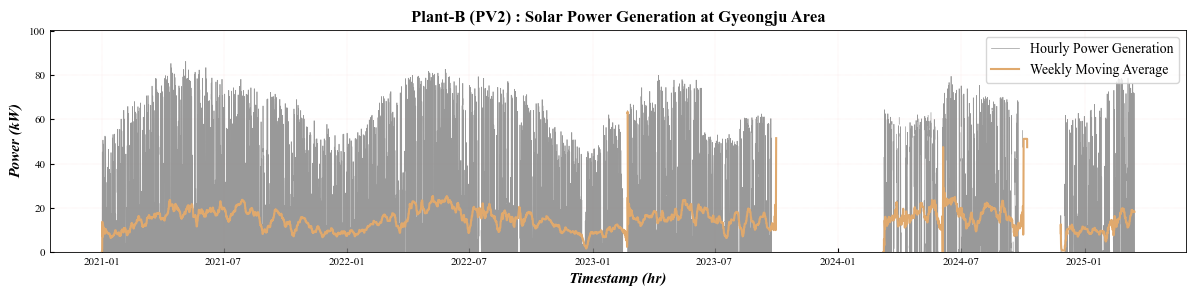

In [46]:
import string

from Library.dataProcessing import plot_pv_generation

for i in range(1, 3):  # Loop through PV1 and PV2 (i=1,2)
    pv = globals()[f"PV{i}"]                       # fetch PV1..PV9 by name
    plant_name = f"Plant-{string.ascii_uppercase[i-1]} (PV{i})"  # i=1 -> A
    plot_pv_generation(pv, PlantName=plant_name, AreaName='Gyeongju Area')

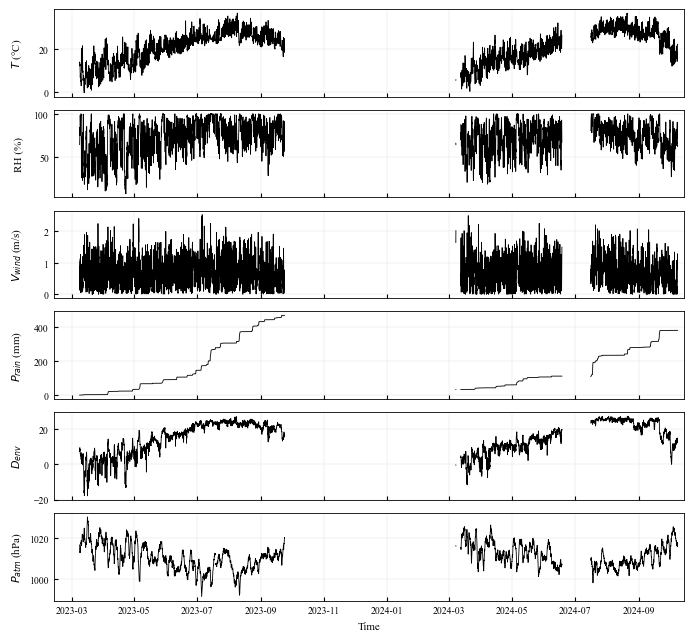

In [47]:
from Library.dataProcessing import plot_weather_data
plot_weather_data(ENV, x_col='timestamp', save_fig=False)

> Combine the most appropriate data into a dataframe

In [48]:
# Ensure datetime index for all three
for df in (PV1, PV2, ENV):
    df['timestamp'] = pd.to_datetime(df['timestamp'])

freq = 'h'   # common time grid — choose 'min', '10min', 'h', etc.

pv1_h = PV1.set_index('timestamp').resample(freq).mean().add_prefix('PV1_')
pv2_h = PV2.set_index('timestamp').resample(freq).mean().add_prefix('PV2_')
env_h = ENV.set_index('timestamp').resample(freq).mean().add_prefix('ENV_')

# Join all three on the shared time index
Site_01 = pv1_h.join([pv2_h, env_h], how='outer').reset_index()

print(Site_01.shape)
Site_01.head()

(36841, 19)


,timestamp,PV1_P_pv,PV1_V_dc,PV1_V_i,PV1_P_dc,PV1_PF,PV1_Freq,PV2_P_pv,PV2_V_dc,PV2_V_i,PV2_P_dc,PV2_PF,PV2_Freq,ENV_T_env,ENV_RH_env,ENV_V_wind,ENV_P_rain,ENV_D_env,ENV_P_atm
0,2021-01-01 00:00:00,0.0,49.259322,0.893220,0.0,0.0,59.954237,0.0,48.421667,0.601667,0.0,0.0,59.945000,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-01 01:00:00,0.0,50.211667,0.895000,0.0,0.0,59.948333,0.0,49.338333,0.601667,0.0,0.0,59.950000,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-01 02:00:00,0.0,50.821053,0.892982,0.0,0.0,59.952632,0.0,49.588333,0.601667,0.0,0.0,59.950000,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-01 03:00:00,0.0,50.701667,0.896667,0.0,0.0,59.965000,0.0,48.981667,0.608333,0.0,0.0,59.958333,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-01 04:00:00,0.0,49.736667,0.901667,0.0,0.0,59.956667,0.0,47.285000,0.605000,0.0,0.0,59.948333,NaN,NaN,NaN,NaN,NaN,NaN


> Fix Meteorological Data

In [49]:
# Check for missing timestamps in the hourly data
Site_01['DT'] = pd.to_datetime(Site_01['timestamp'])
Site_01 = Site_01.set_index('DT').sort_index()

full = pd.date_range(Site_01.index.min(), Site_01.index.max(), freq='h')

missing = full.difference(Site_01.index)
print(f"{len(missing)} missing timestamps")
print(missing)

# add the missing rows (values become NaN)
Site_01.index.name = 'DT'

0 missing timestamps
DatetimeIndex([], dtype='datetime64[ns]', freq='h')


In [50]:
ENV_Rename_COLS = {
    'ENV_T_env'    : 'T_env_C',
    'ENV_RH_env'   : 'H_env_%',
    'ENV_V_wind'   : 'V_wind_m/s',
    'ENV_P_rain'   : 'P_rain_mm/h',
    'ENV_D_env'    : 'D_env_g/m^3',
    'ENV_P_atm'    : 'P_atm_hPa',
}
Site_01 = Site_01.rename(columns=ENV_Rename_COLS)

In [51]:
ENV_COLS = ['T_env_C', 'H_env_%', 'V_wind_m/s', 'P_rain_mm/h', 'D_env_g/m^3', 'P_atm_hPa']

In [52]:
print('NaNs before:')
print(Site_01[ENV_COLS].isna().sum(), '\n')


importlib.reload(Library.dataProcessing)
from Library.dataProcessing import fix_env_nans

Site_01_filled, synthesized = fix_env_nans(Site_01, rain_is_cumulative=True, add_noise=True)

print('NaNs after:')
print(Site_01_filled[ENV_COLS].isna().sum(), '\n')
print('Synthesized (reconstructed) rows per column:')
print(synthesized.sum())

NaNs before:
T_env_C        27598
H_env_%        27598
V_wind_m/s     27598
P_rain_mm/h    27598
D_env_g/m^3    27598
P_atm_hPa      27598
dtype: int64 

NaNs after:
T_env_C        0
H_env_%        0
V_wind_m/s     0
P_rain_mm/h    0
D_env_g/m^3    0
P_atm_hPa      0
dtype: int64 

Synthesized (reconstructed) rows per column:
T_env_C        27598
H_env_%        27598
V_wind_m/s     27600
P_rain_mm/h    27598
D_env_g/m^3    27598
P_atm_hPa      27702
dtype: int64


> Fix Solar Generation Data

In [53]:
selected_columns = Site_01.columns.drop(['timestamp']).tolist()
selected_columns

['PV1_P_pv',
 'PV1_V_dc',
 'PV1_V_i',
 'PV1_P_dc',
 'PV1_PF',
 'PV1_Freq',
 'PV2_P_pv',
 'PV2_V_dc',
 'PV2_V_i',
 'PV2_P_dc',
 'PV2_PF',
 'PV2_Freq',
 'T_env_C',
 'H_env_%',
 'V_wind_m/s',
 'P_rain_mm/h',
 'D_env_g/m^3',
 'P_atm_hPa']

In [54]:
PV_COLS = selected_columns[:(len(PV1.columns)-1)*2]  
PV_COLS

['PV1_P_pv',
 'PV1_V_dc',
 'PV1_V_i',
 'PV1_P_dc',
 'PV1_PF',
 'PV1_Freq',
 'PV2_P_pv',
 'PV2_V_dc',
 'PV2_V_i',
 'PV2_P_dc',
 'PV2_PF',
 'PV2_Freq']

In [55]:
print('NaNs before:')
print(Site_01[PV_COLS].isna().sum(), '\n')

importlib.reload(Library.dataProcessing)
from Library.dataProcessing import fix_pv_nans

Site_01_filled, synthesized = fix_pv_nans(Site_01, pv_cols=PV_COLS, seed=42)

print('NaNs after:')
print(Site_01_filled[PV_COLS].isna().sum(), '\n')
print('Synthesized (reconstructed) rows per column:')
print(synthesized.sum())


NaNs before:
PV1_P_pv    9403
PV1_V_dc    9403
PV1_V_i     9403
PV1_P_dc    9403
PV1_PF      9403
PV1_Freq    9403
PV2_P_pv    7604
PV2_V_dc    7604
PV2_V_i     7604
PV2_P_dc    7604
PV2_PF      7604
PV2_Freq    7604
dtype: int64 

NaNs after:
PV1_P_pv    0
PV1_V_dc    0
PV1_V_i     0
PV1_P_dc    0
PV1_PF      0
PV1_Freq    0
PV2_P_pv    0
PV2_V_dc    0
PV2_V_i     0
PV2_P_dc    0
PV2_PF      0
PV2_Freq    0
dtype: int64 

Synthesized (reconstructed) rows per column:
PV1_P_pv    9403
PV1_V_dc    9403
PV1_V_i     9403
PV1_P_dc    9403
PV1_PF      9403
PV1_Freq    9403
PV2_P_pv    7604
PV2_V_dc    7604
PV2_V_i     7604
PV2_P_dc    7604
PV2_PF      7604
PV2_Freq    7619
dtype: int64


> Finalization

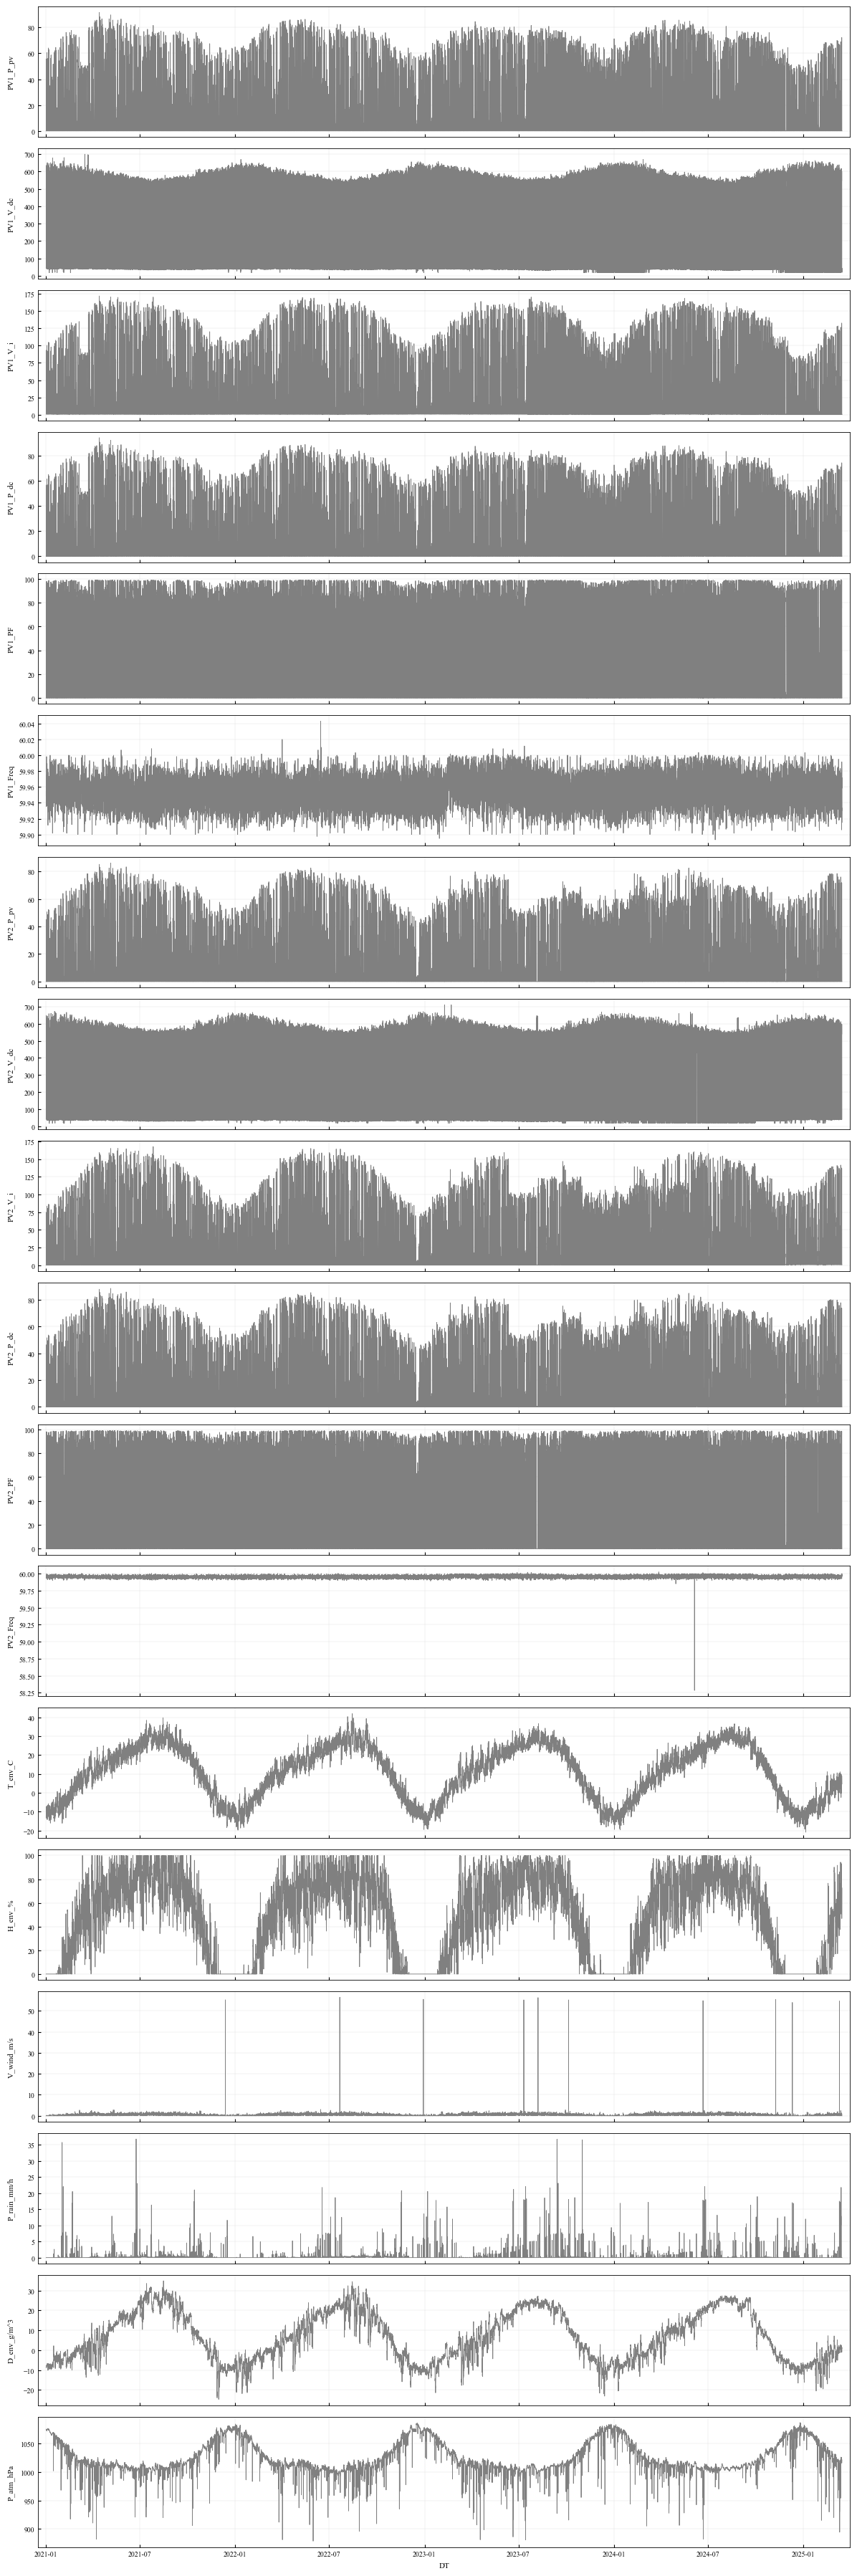

(<Figure size 1200x3600 with 18 Axes>,
 array([<Axes: ylabel='PV1_P_pv'>, <Axes: ylabel='PV1_V_dc'>,
        <Axes: ylabel='PV1_V_i'>, <Axes: ylabel='PV1_P_dc'>,
        <Axes: ylabel='PV1_PF'>, <Axes: ylabel='PV1_Freq'>,
        <Axes: ylabel='PV2_P_pv'>, <Axes: ylabel='PV2_V_dc'>,
        <Axes: ylabel='PV2_V_i'>, <Axes: ylabel='PV2_P_dc'>,
        <Axes: ylabel='PV2_PF'>, <Axes: ylabel='PV2_Freq'>,
        <Axes: ylabel='T_env_C'>, <Axes: ylabel='H_env_%'>,
        <Axes: ylabel='V_wind_m/s'>, <Axes: ylabel='P_rain_mm/h'>,
        <Axes: ylabel='D_env_g/m^3'>,
        <Axes: xlabel='DT', ylabel='P_atm_hPa'>], dtype=object))

In [56]:
importlib.reload(Library.dataProcessing)
from Library.dataProcessing import plot_selected_columns
plot_selected_columns(Site_01_filled, selected_columns, x='DT')

In [57]:
Site_01_filled.describe()

,timestamp,PV1_P_pv,PV1_V_dc,PV1_V_i,PV1_P_dc,PV1_PF,PV1_Freq,PV2_P_pv,PV2_V_dc,PV2_V_i,PV2_P_dc,PV2_PF,PV2_Freq,T_env_C,H_env_%,V_wind_m/s,P_rain_mm/h,D_env_g/m^3,P_atm_hPa
count,36841,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000,36841.000000
mean,2023-02-07 12:00:00,14.851077,321.916272,28.066871,15.217101,39.894532,59.953744,14.034974,323.373950,26.347758,14.406920,39.948645,59.953405,10.650806,47.633128,0.475231,0.180534,6.982169,1027.820653
min,2021-01-01 00:00:00,0.000000,17.335000,0.401667,0.000000,0.000000,59.893333,0.000000,16.790000,0.278000,0.000000,0.000000,58.282857,-20.913248,0.000000,0.000000,0.000000,-24.760329,878.686619
25%,2022-01-19 18:00:00,0.000000,38.366667,0.788333,0.000000,0.000000,59.941667,0.000000,35.241667,0.498333,0.000000,0.000000,59.941667,-1.593883,4.124794,0.000000,0.000000,-3.832407,1008.875000
50%,2023-02-07 12:00:00,0.395000,496.678333,1.501667,0.793478,9.151667,59.953333,0.318333,497.103333,1.231667,0.638182,7.874576,59.953333,12.723389,54.636317,0.356667,0.000000,6.094391,1017.651667
75%,2024-02-26 06:00:00,24.145000,560.548333,43.080000,24.753333,86.201852,59.965000,23.333333,564.572414,41.805000,23.883333,87.413333,59.965000,22.981667,78.053333,0.762168,0.053058,18.205265,1047.537530
max,2025-03-16 00:00:00,91.711667,700.500000,171.611667,94.041667,99.433333,60.042857,86.218333,711.200000,167.838333,88.450000,99.350000,60.025000,41.934775,100.000000,56.526031,36.799434,34.970560,1087.225479
std,NaN,22.621277,256.600469,42.537363,23.036954,42.506630,0.017590,21.059639,258.757606,39.632139,21.534160,42.712356,0.019729,14.018711,34.938067,1.015488,1.042624,12.239347,25.767905


In [58]:
Site_01_filled.to_csv(f"{preDataDirectory}Site#01_Data.gzip", index=False, compression="gzip")
Site_01_filled.to_csv(f"{dataDirectory}Site#01_Data.gzip", index=False, compression="gzip")

print('=' * 40)
print("Site#01 combined data saved")
print('-'*40)
print(f'In  "{preDataDirectory}Site#01_Data.gzip"')
print(f'and "{dataDirectory}Site#01_Data.gzip"')
print('=' * 40)

Site#01 combined data saved
----------------------------------------
In  "../../Database/2026-06-14/Preprocessed/Site#01_Data.gzip"
and "../Export/Data/Site#01_Data.gzip"
